# Self-report vs Behavior task Correlations

### Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import libraries.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

Build dataframe

In [13]:
df = pd.read_csv("data.csv", encoding="utf-8-sig")
df.head()

,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,crosswalk_used_ratio_mid_penalty,crosswalk_used_ratio_high_penalty,jaywalking_ratio_total,jaywalking_ratio_easy,jaywalking_ratio_hard,jaywalking_ratio_low_penalty,jaywalking_ratio_mid_penalty,jaywalking_ratio_high_penalty,DDT_mean_log_k,CRA_mean_alpha
0,100,29,2,16,77,30,25,22,96,45,...,0.176471,0.181818,0.289474,0.300000,0.282609,0.300000,0.264706,0.318182,-6.945853,0.851175
1,502,1001,2,12,79,31,25,23,104,51,...,0.037736,0.051852,0.270081,0.268987,0.270718,0.261993,0.286164,0.259259,-4.945853,0.751175
2,503,1901,1,1234,80,36,24,20,109,56,...,0.052023,0.041420,0.242483,0.234043,0.247328,0.253602,0.236994,0.236686,-2.945853,1.111751


Utils

In [14]:
def scatter_plot_with_line_regression(plot, x, y, xlabel, ylabel, title):
    plot.scatter(x, y)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    plot.plot(line_x, line_y, color="red")

    plot.set_xlabel(xlabel)
    plot.set_ylabel(ylabel)
    plot.set_title(f"{title}\nr={r_value:.3f}")

## Self-report vs Traditional Behavior Tasks

### DDT: Delay Discounting Task
- DDT: Discounting Rate `k`
- BIS: impulsivity

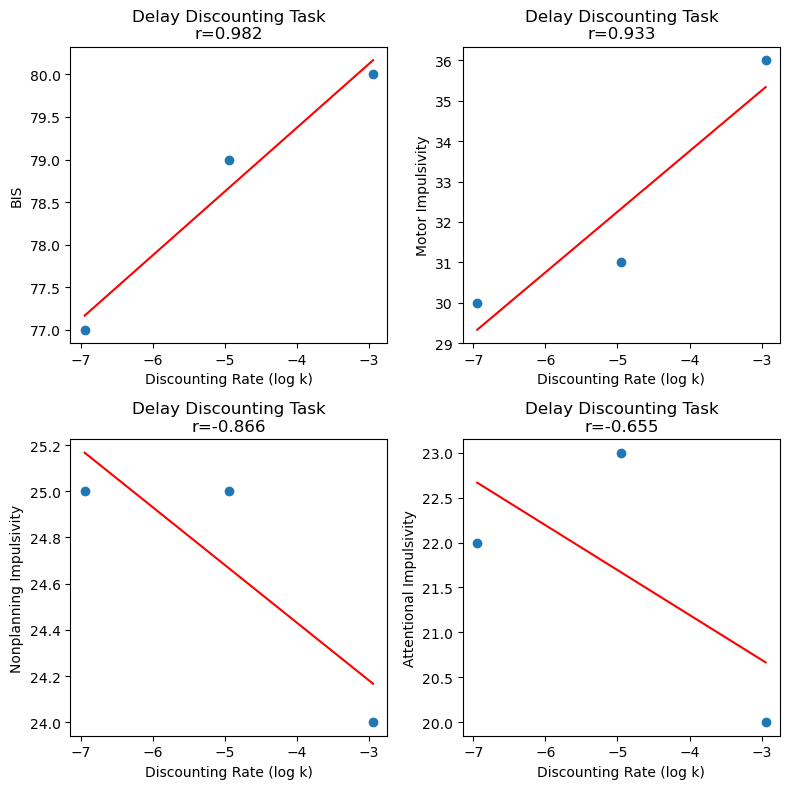

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
title = "Delay Discounting Task"
x = df["DDT_mean_log_k"]
xlabel = "Discounting Rate (log k)"
scatter_plot_with_line_regression(axes[0, 0], x, df["BIS"], xlabel, "BIS", title)
scatter_plot_with_line_regression(axes[0, 1], x, df["BIS_motor"], xlabel, "Motor Impulsivity", title)
scatter_plot_with_line_regression(axes[1, 0], x, df["BIS_nonplanning"], xlabel, "Nonplanning Impulsivity", title)
scatter_plot_with_line_regression(axes[1, 1], x, df["BIS_attentional"], xlabel, "Attentional Impulsivity", title)

plt.tight_layout()
plt.show()

### CRA: Choice under Risk and Ambiguity Task

- CRA: risk preference parameter `alpha`
- DOSPERT: Risk Taking

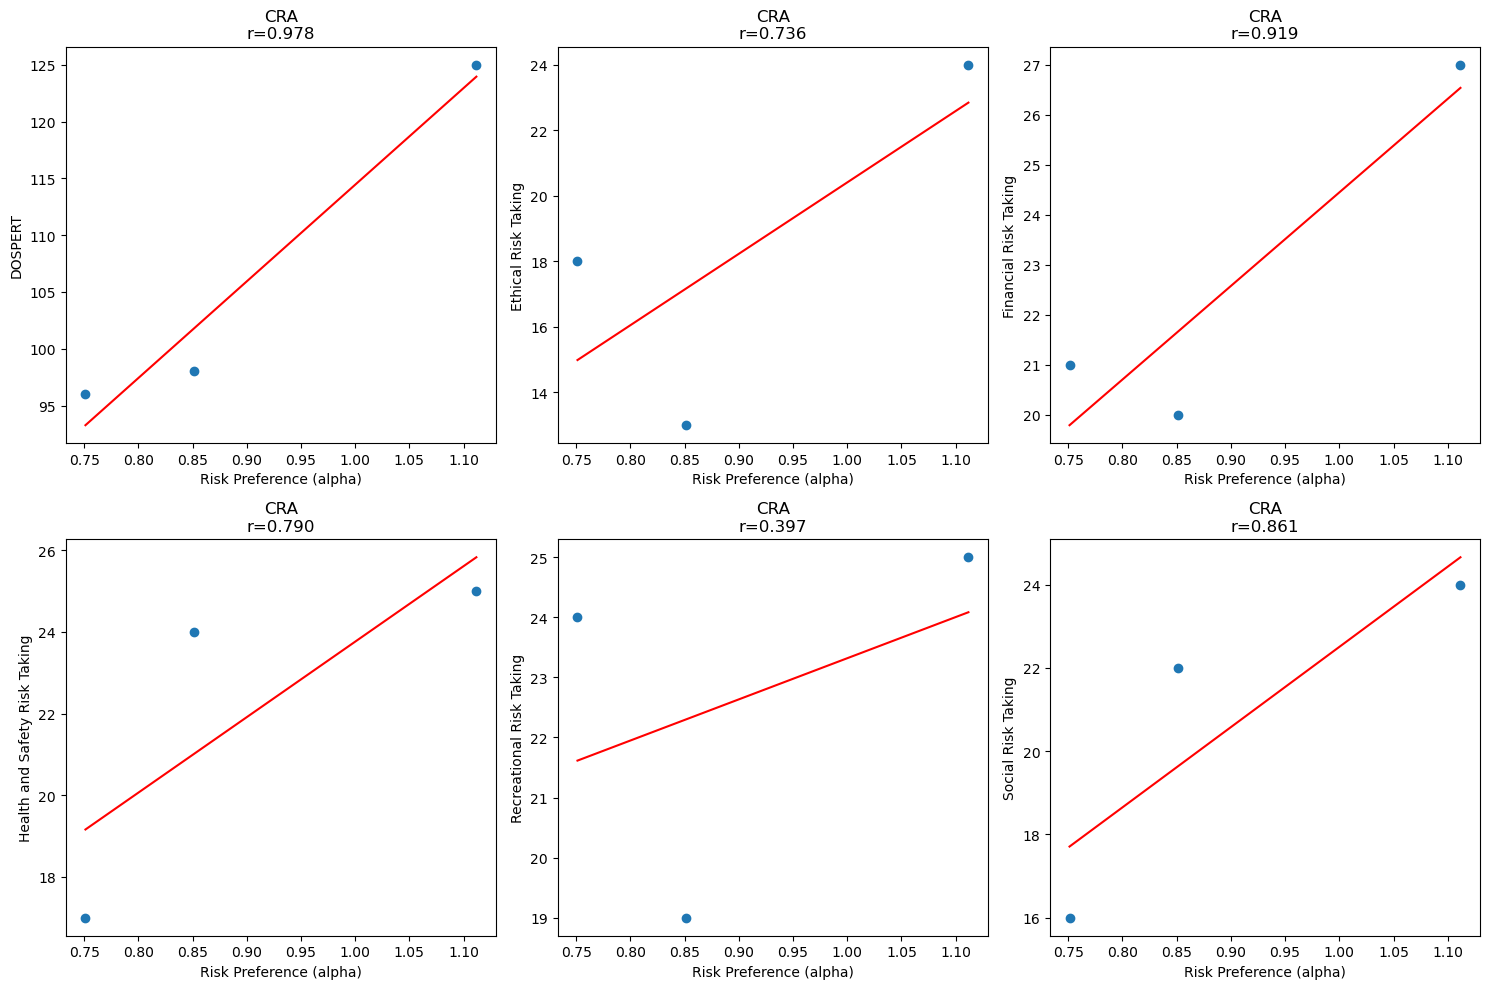

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
title = "CRA"
x = df["CRA_mean_alpha"]
xlabel = "Risk Preference (alpha)"
scatter_plot_with_line_regression(axes[0, 0], x, df["DOSPERT"], xlabel, "DOSPERT", title)
scatter_plot_with_line_regression(axes[0, 1], x, df["DOSPERT_ETH"], xlabel, "Ethical Risk Taking", title)
scatter_plot_with_line_regression(axes[0, 2], x, df["DOSPERT_FIN"], xlabel, "Financial Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 0], x, df["DOSPERT_HEA"], xlabel, "Health and Safety Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 1], x, df["DOSPERT_REC"], xlabel, "Recreational Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 2], x, df["DOSPERT_SOC"], xlabel, "Social Risk Taking", title)
plt.tight_layout()
plt.show()

## Self-report vs Pedestrian Task

### Pedestrian Task Scores

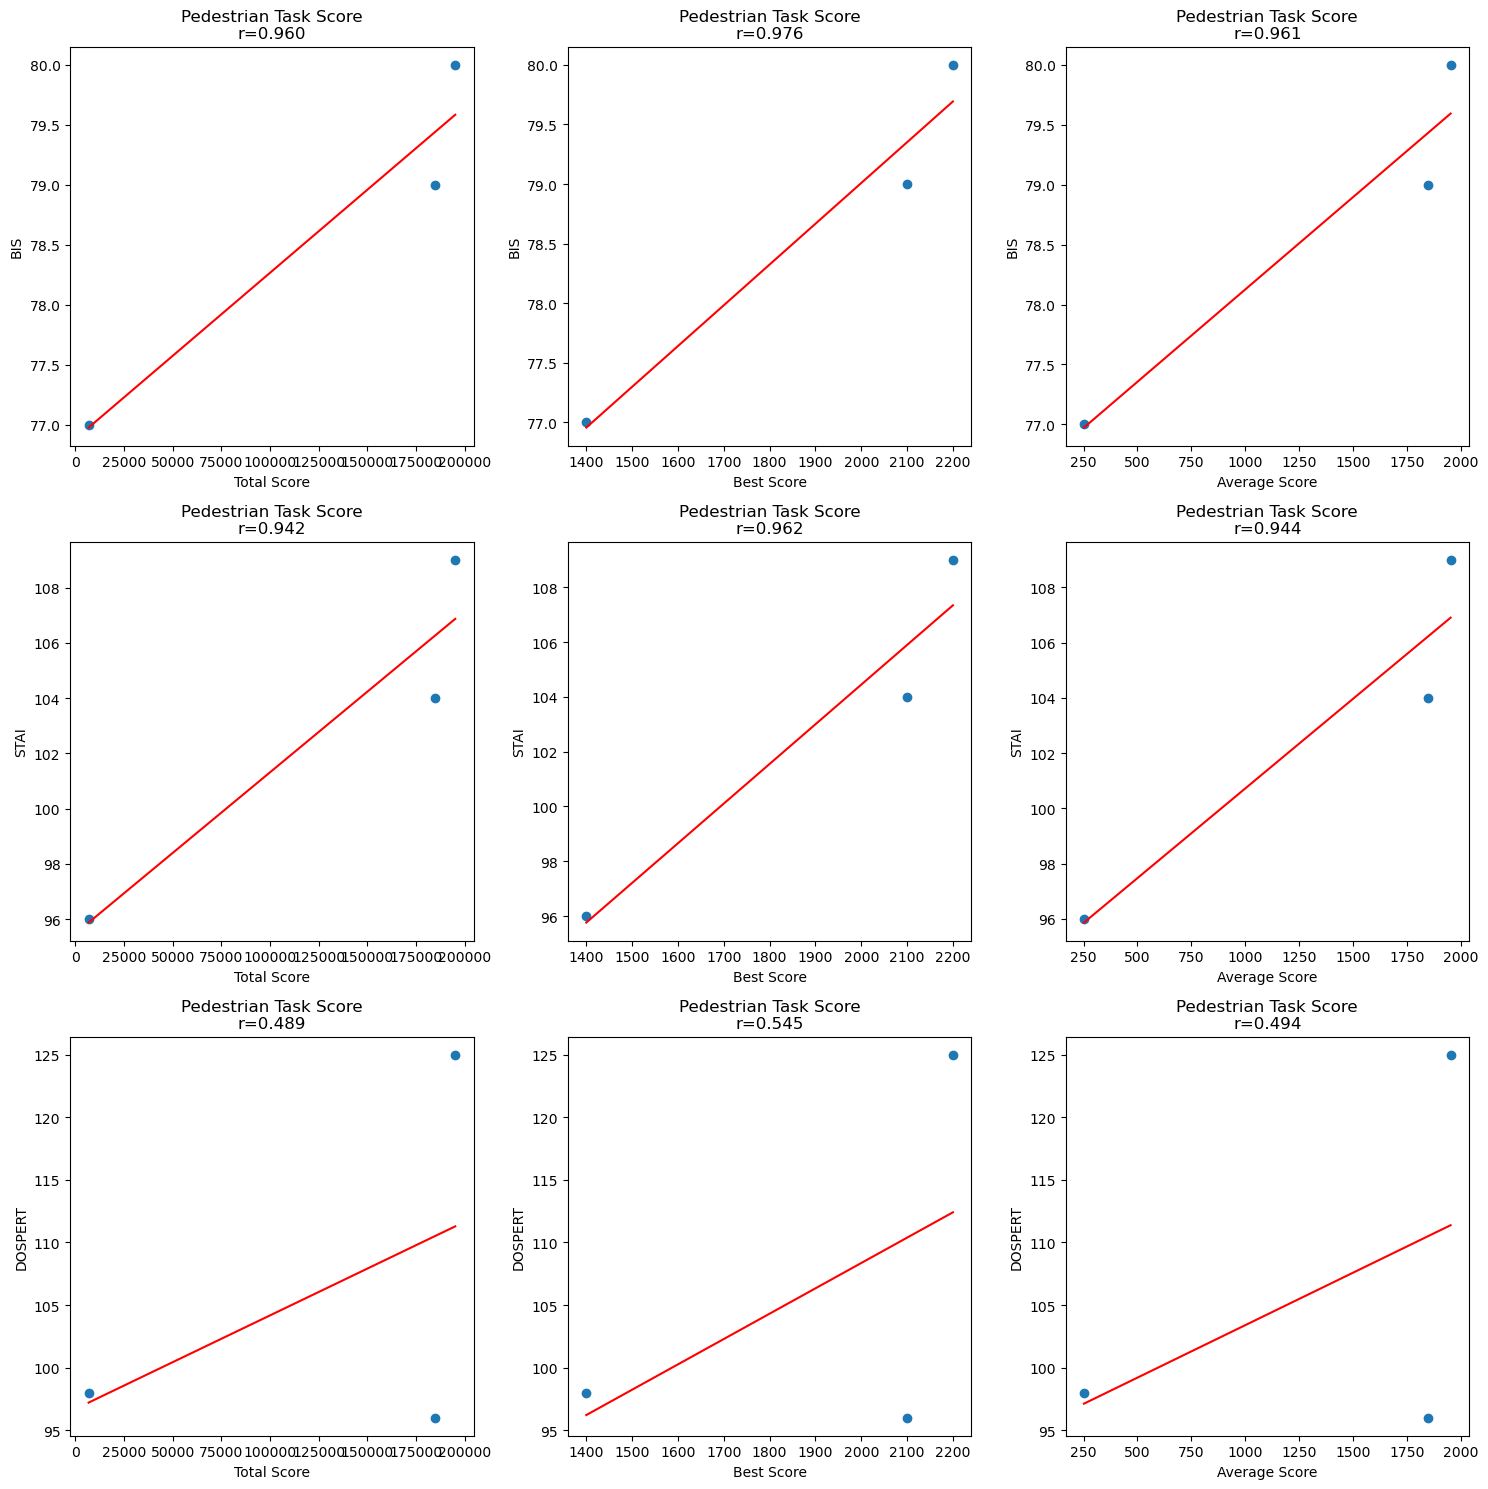

In [16]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]
row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 5 * row_count))
for i in range(row_count):
    questionnaire = questionnaires[i]
    scores = ["total_score_full", "best_score_full", "average_score_full"]
    xlabels = ["Total Score", "Best Score", "Average Score"]
    for j in range(3):
        x = df[scores[j]]
        y = df[questionnaire]
        scatter_plot_with_line_regression(axes[i, j], x, y, xlabels[j], questionnaire, title="Pedestrian Task Score")

plt.tight_layout()
plt.show()

### Crosswalk Usage Ratio

In [35]:
col_types = ["total", "easy", "hard", "low_penalty", "mid_penalty", "high_penalty"]
xlables = ["Total", "Easy", "Hard", "Low Penalty", "Mid Penalty", "High Penalty"]

#### Entered Road with Crosswalk Ratio 

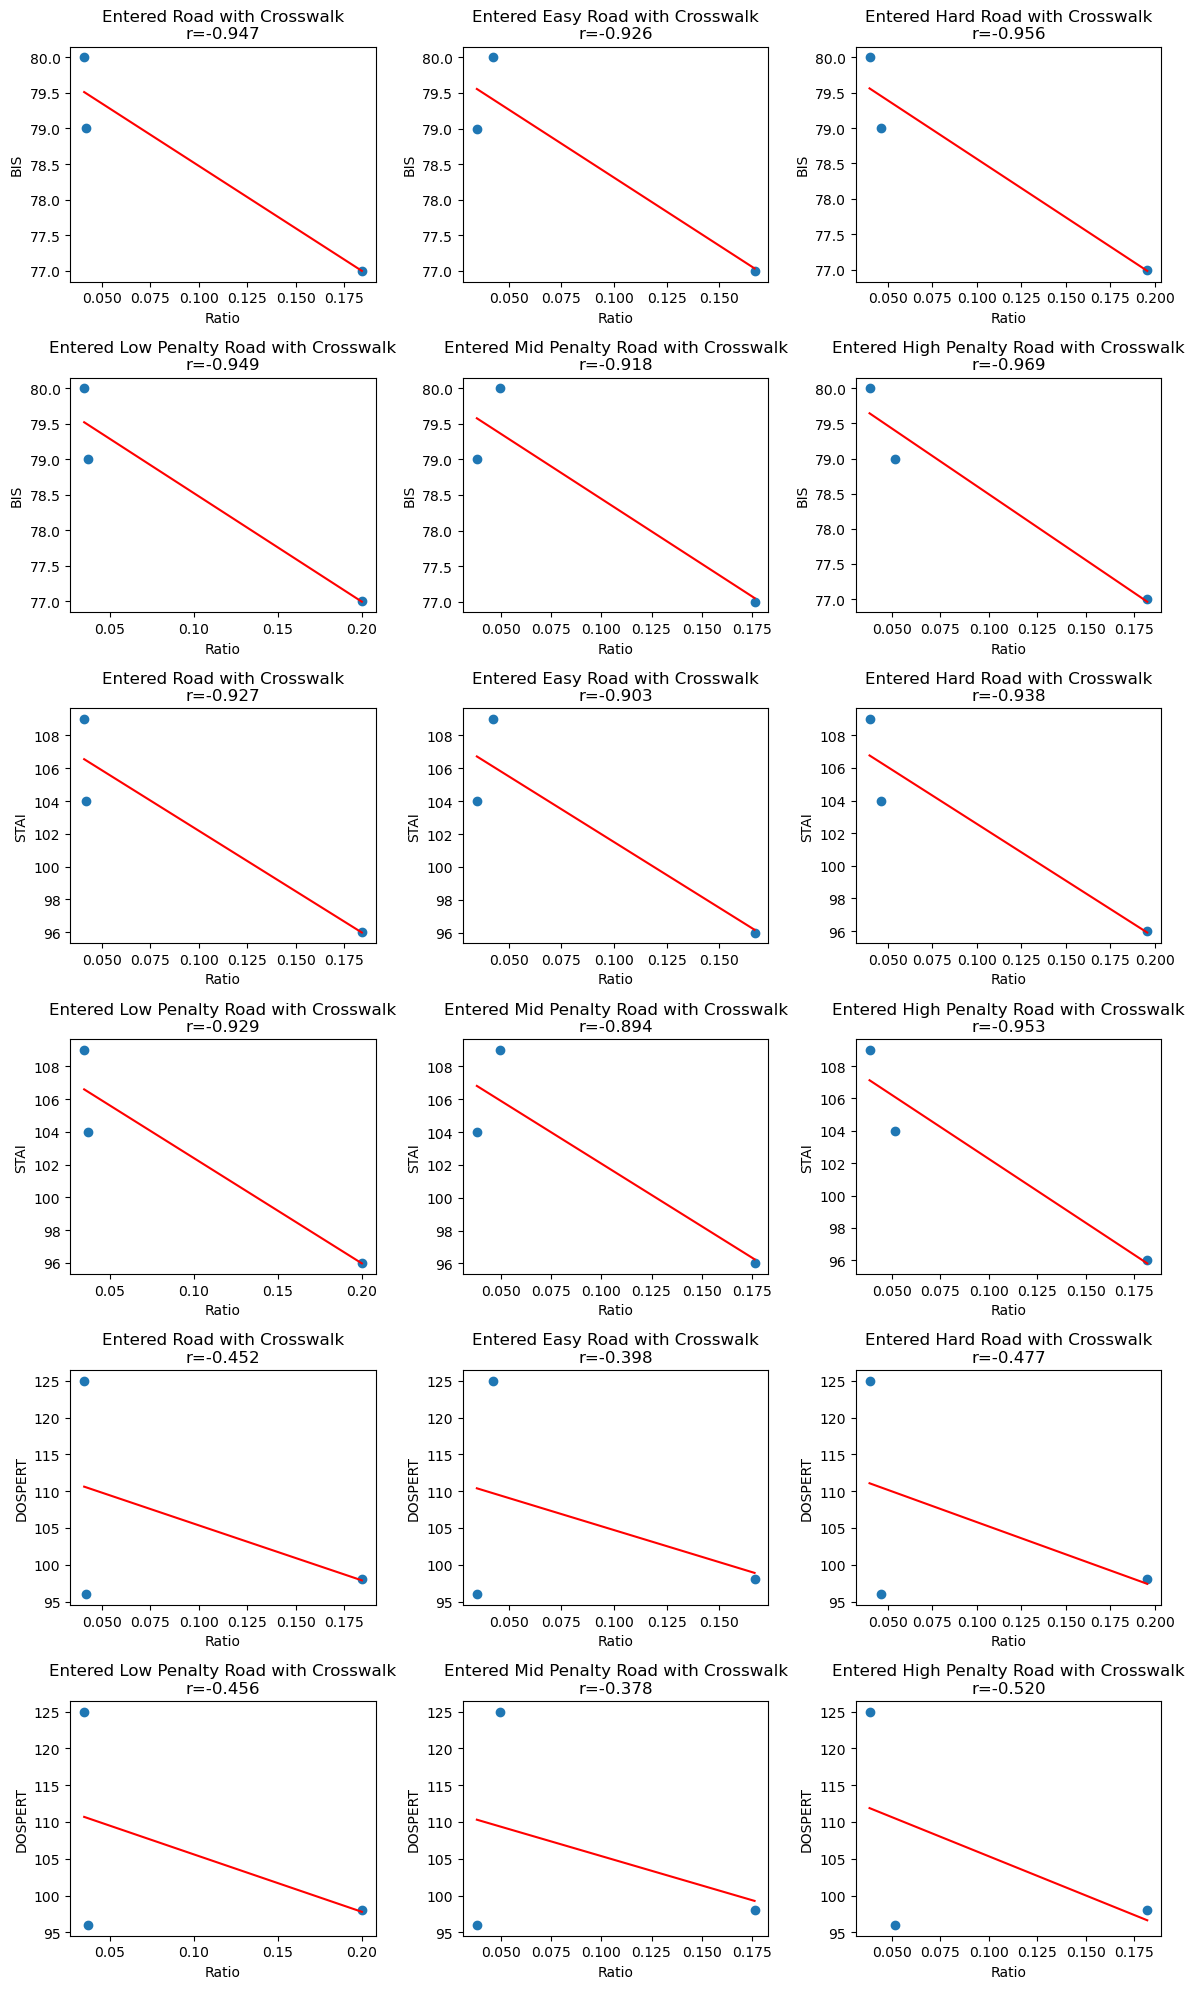

In [41]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

fig, axes = plt.subplots(len(questionnaires) * 2, 3, figsize=(12, 20))
for i in range(len(questionnaires)):
    questionnaire = questionnaires[i]
    for j in range(len(col_types)):
        idx = 2 * len(questionnaires) * i + j
        col = f"entered_road_with_crosswalk_{col_types[j]}"
        x = df[col]
        y = df[questionnaire]
        title = [
            "Entered Road with Crosswalk", "Entered Easy Road with Crosswalk", "Entered Hard Road with Crosswalk",
            "Entered Low Penalty Road with Crosswalk", "Entered Mid Penalty Road with Crosswalk", "Entered High Penalty Road with Crosswalk",
        ][j]
        scatter_plot_with_line_regression(axes[idx // 3, idx % 3], x, y, "Ratio", questionnaire, title=title)
plt.tight_layout()
plt.show()

#### Entered Road without Crosswalk Ratio 

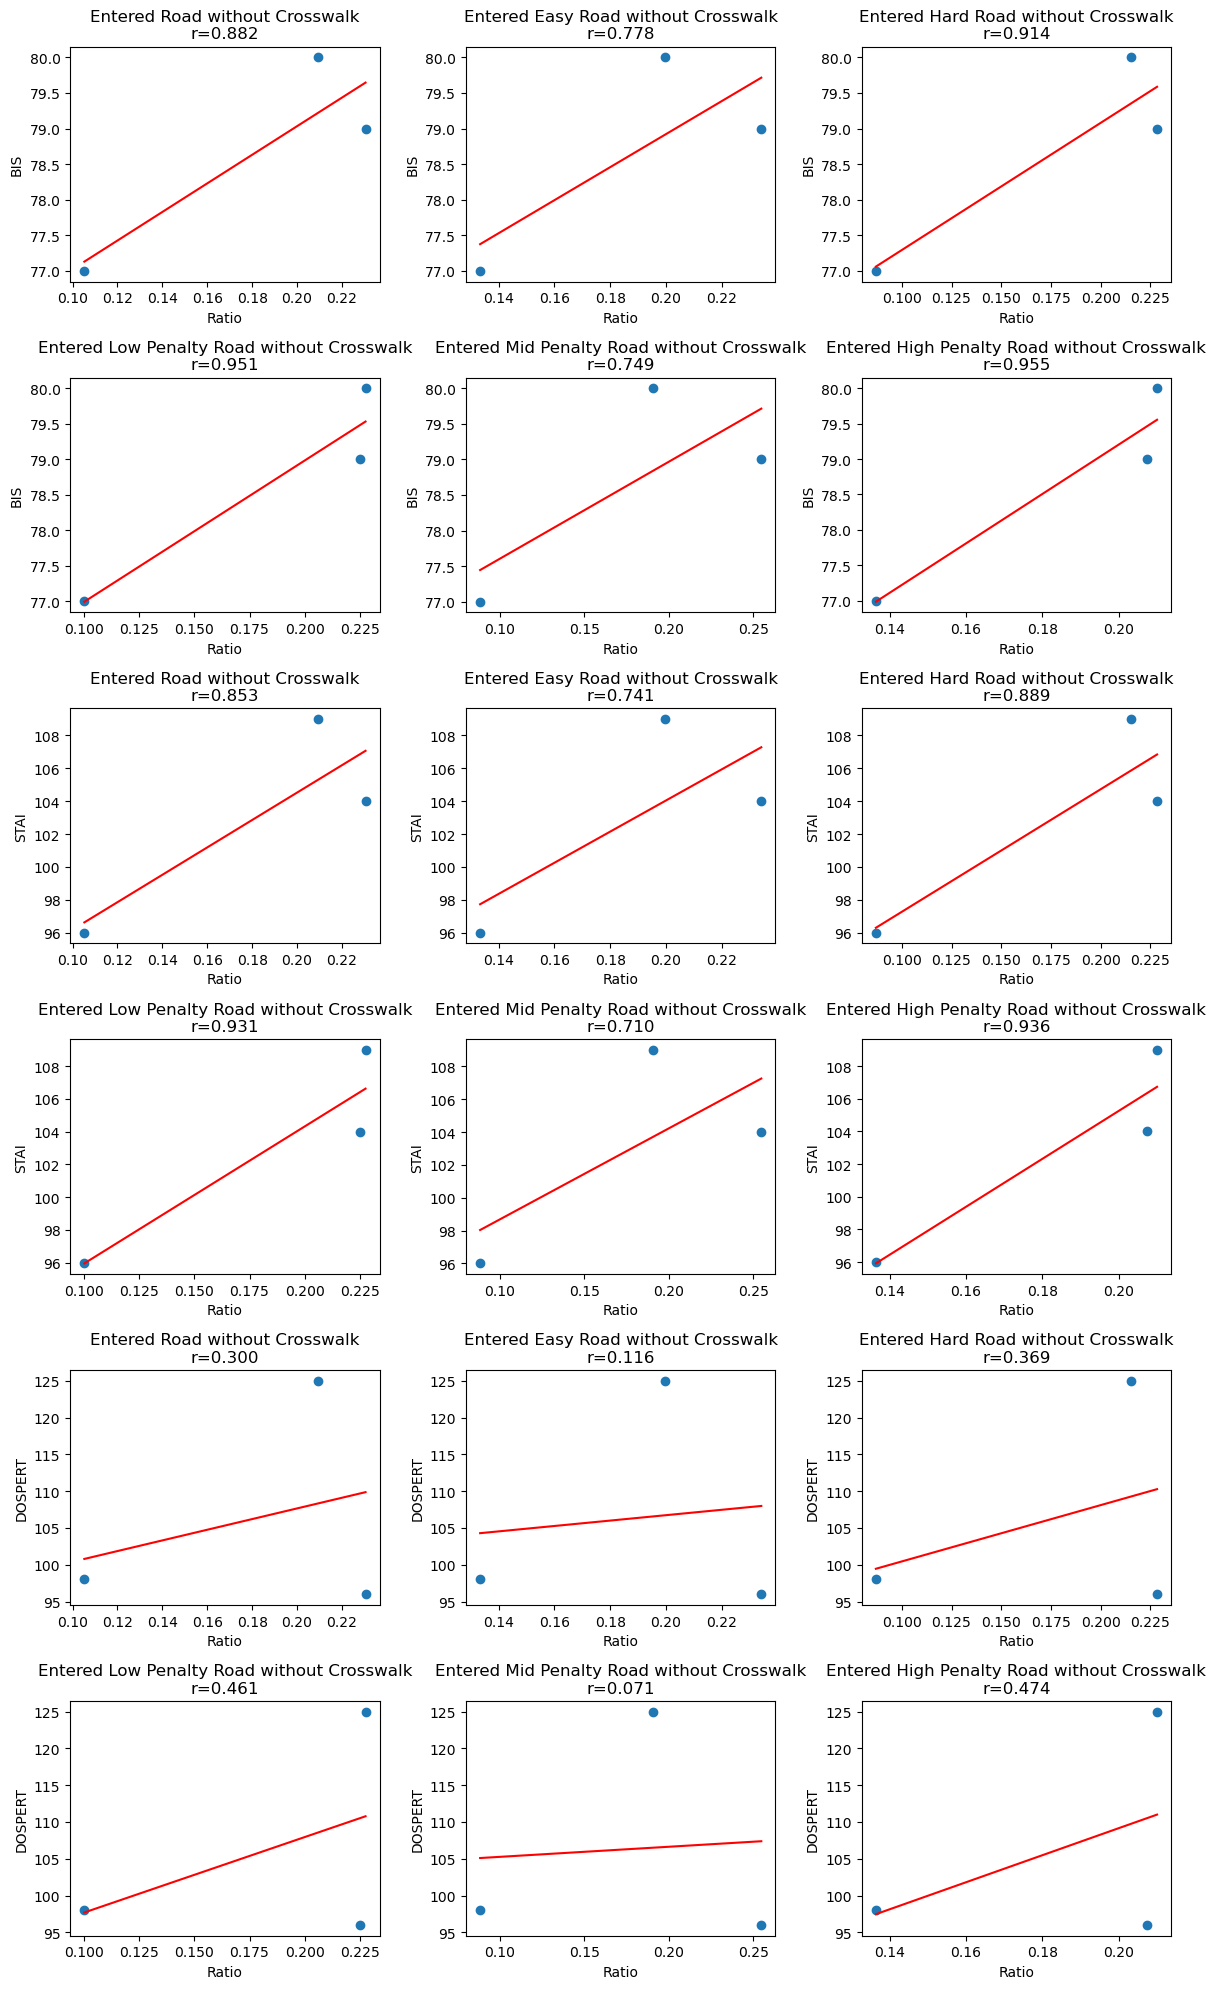

In [44]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

fig, axes = plt.subplots(len(questionnaires) * 2, 3, figsize=(12, 20))
for i in range(len(questionnaires)):
    questionnaire = questionnaires[i]
    for j in range(len(col_types)):
        idx = 2 * len(questionnaires) * i + j
        col = f"entered_road_ignoring_crosswalk_{col_types[j]}"
        x = df[col]
        y = df[questionnaire]
        title = [
            "Entered Road without Crosswalk", "Entered Easy Road without Crosswalk", "Entered Hard Road without Crosswalk",
            "Entered Low Penalty Road without Crosswalk", "Entered Mid Penalty Road without Crosswalk", "Entered High Penalty Road without Crosswalk",
        ][j]
        scatter_plot_with_line_regression(axes[idx // 3, idx % 3], x, y, "Ratio", questionnaire, title=title)
plt.tight_layout()
plt.show()

#### Crosswalk Full Usage Ratio

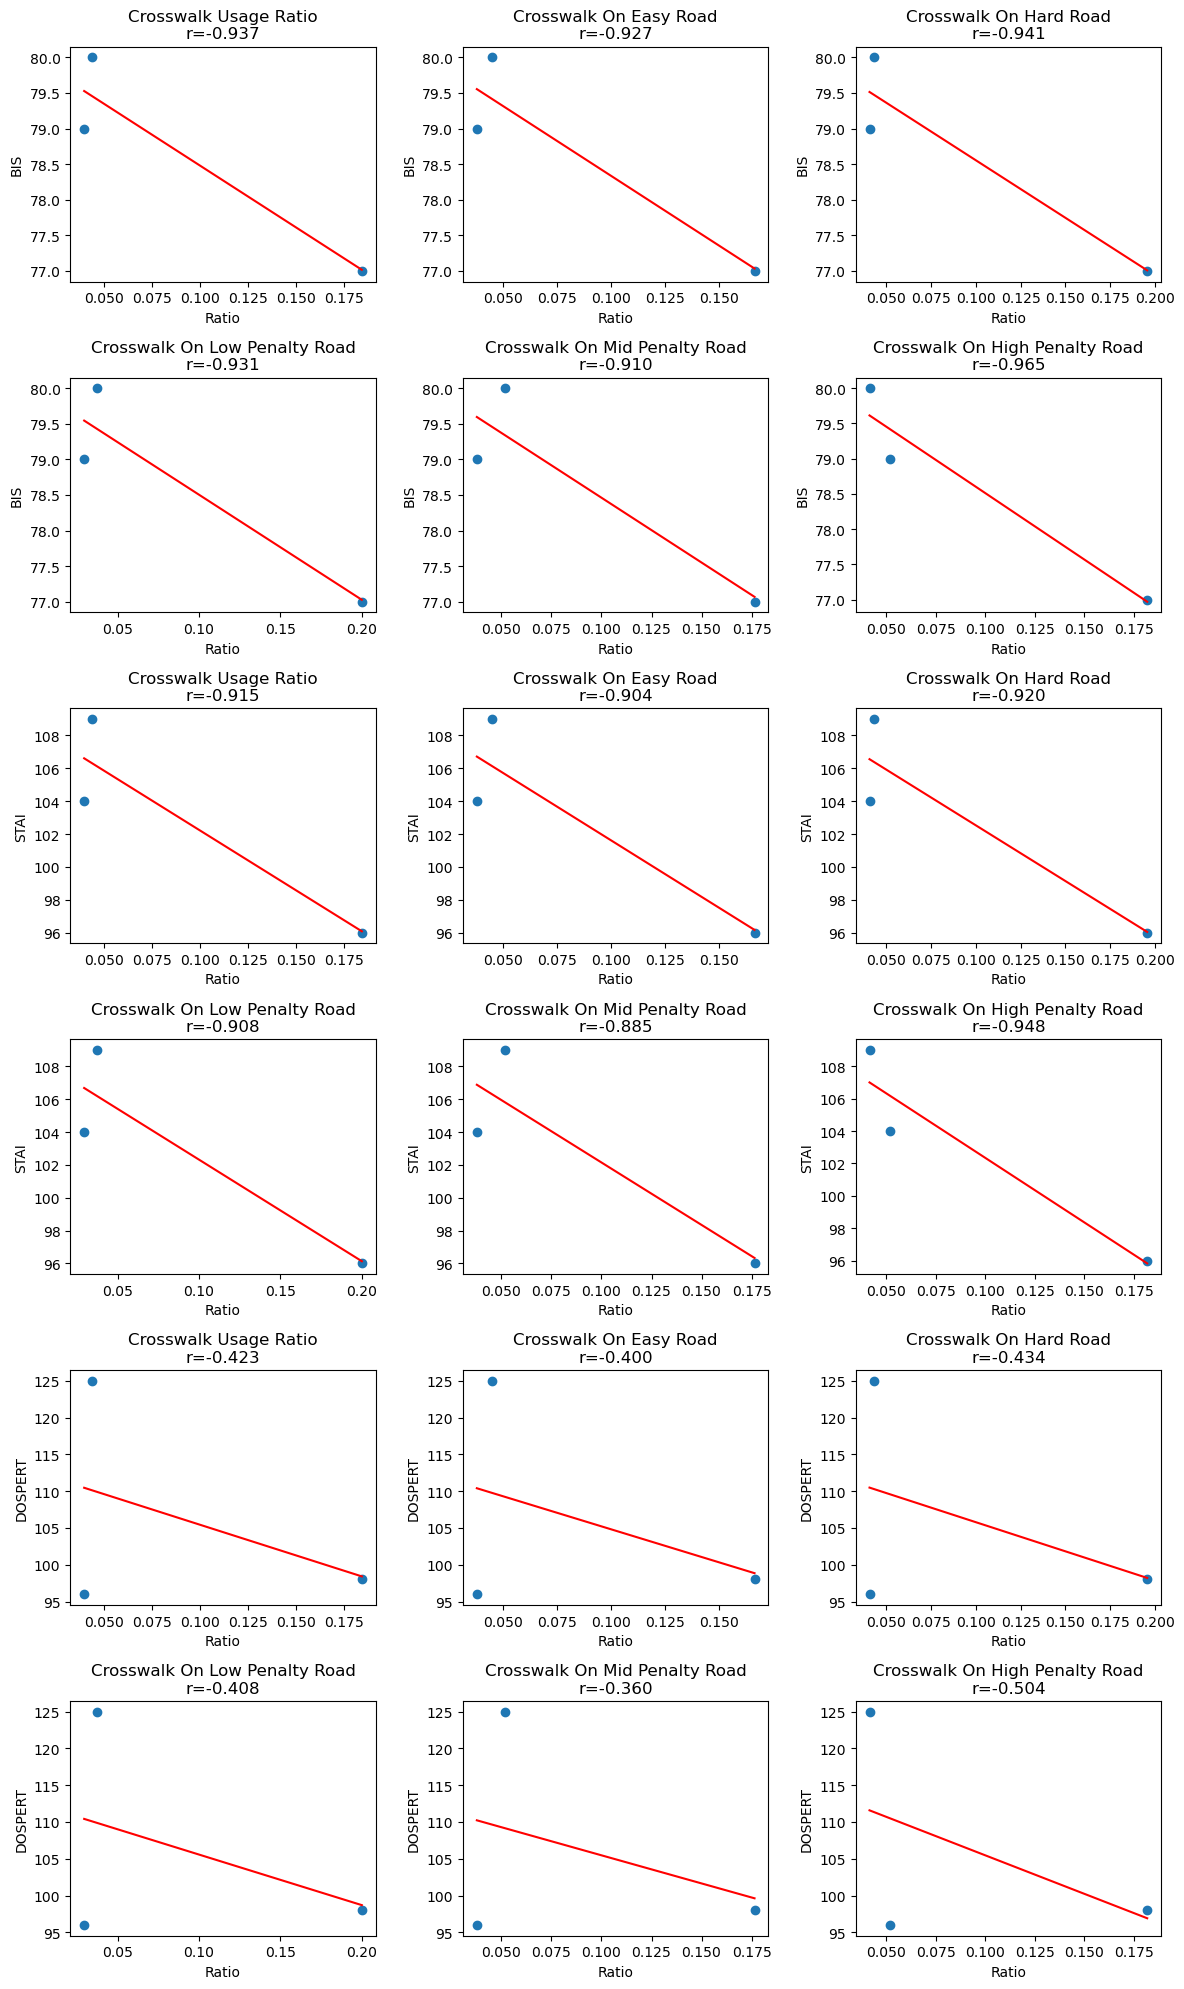

In [43]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

fig, axes = plt.subplots(len(questionnaires) * 2, 3, figsize=(12, 20))
for i in range(len(questionnaires)):
    questionnaire = questionnaires[i]
    for j in range(len(col_types)):
        idx = 2 * len(questionnaires) * i + j
        col = f"crosswalk_used_ratio_{col_types[j]}"
        x = df[col]
        y = df[questionnaire]
        title = [
            "Crosswalk Usage Ratio", "Crosswalk On Easy Road", "Crosswalk On Hard Road",
            "Crosswalk On Low Penalty Road", "Crosswalk On Mid Penalty Road", "Crosswalk On High Penalty Road",
        ][j]
        scatter_plot_with_line_regression(axes[idx // 3, idx % 3], x, y, "Ratio", questionnaire, title=title)
plt.tight_layout()
plt.show()

#### Jaywalking Ratio

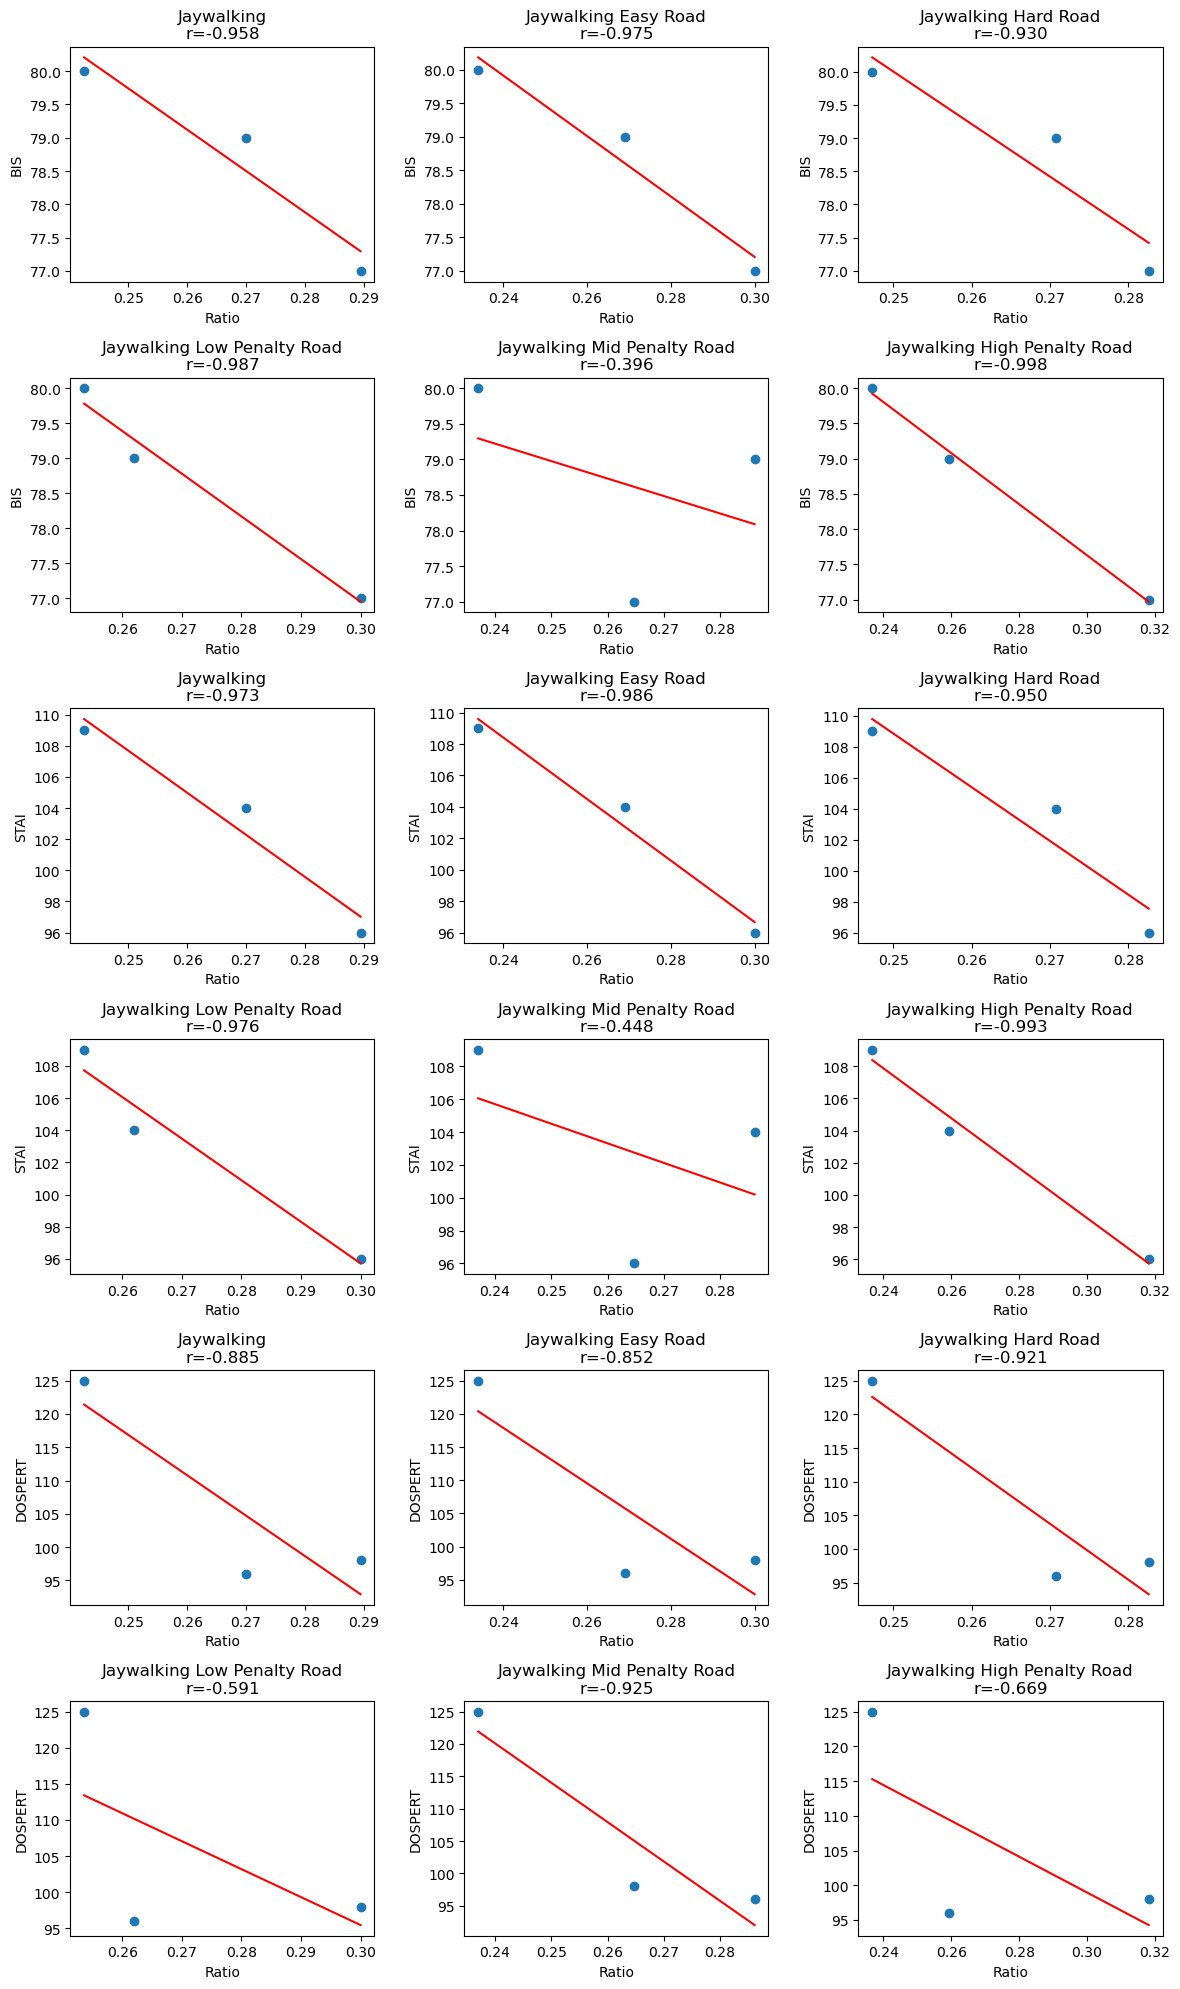

In [42]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

fig, axes = plt.subplots(len(questionnaires) * 2, 3, figsize=(12, 20))
for i in range(len(questionnaires)):
    questionnaire = questionnaires[i]
    for j in range(len(col_types)):
        idx = 2 * len(questionnaires) * i + j
        col = f"jaywalking_ratio_{col_types[j]}"
        x = df[col]
        y = df[questionnaire]
        title = [
            "Jaywalking", "Jaywalking Easy Road", "Jaywalking Hard Road",
            "Jaywalking Low Penalty Road", "Jaywalking Mid Penalty Road", "Jaywalking High Penalty Road",
        ][j]
        scatter_plot_with_line_regression(axes[idx // 3, idx % 3], x, y, "Ratio", questionnaire, title=title)
plt.tight_layout()
plt.show()

### Episode Results

#### Bonus score, Timeover, Runover Ratios

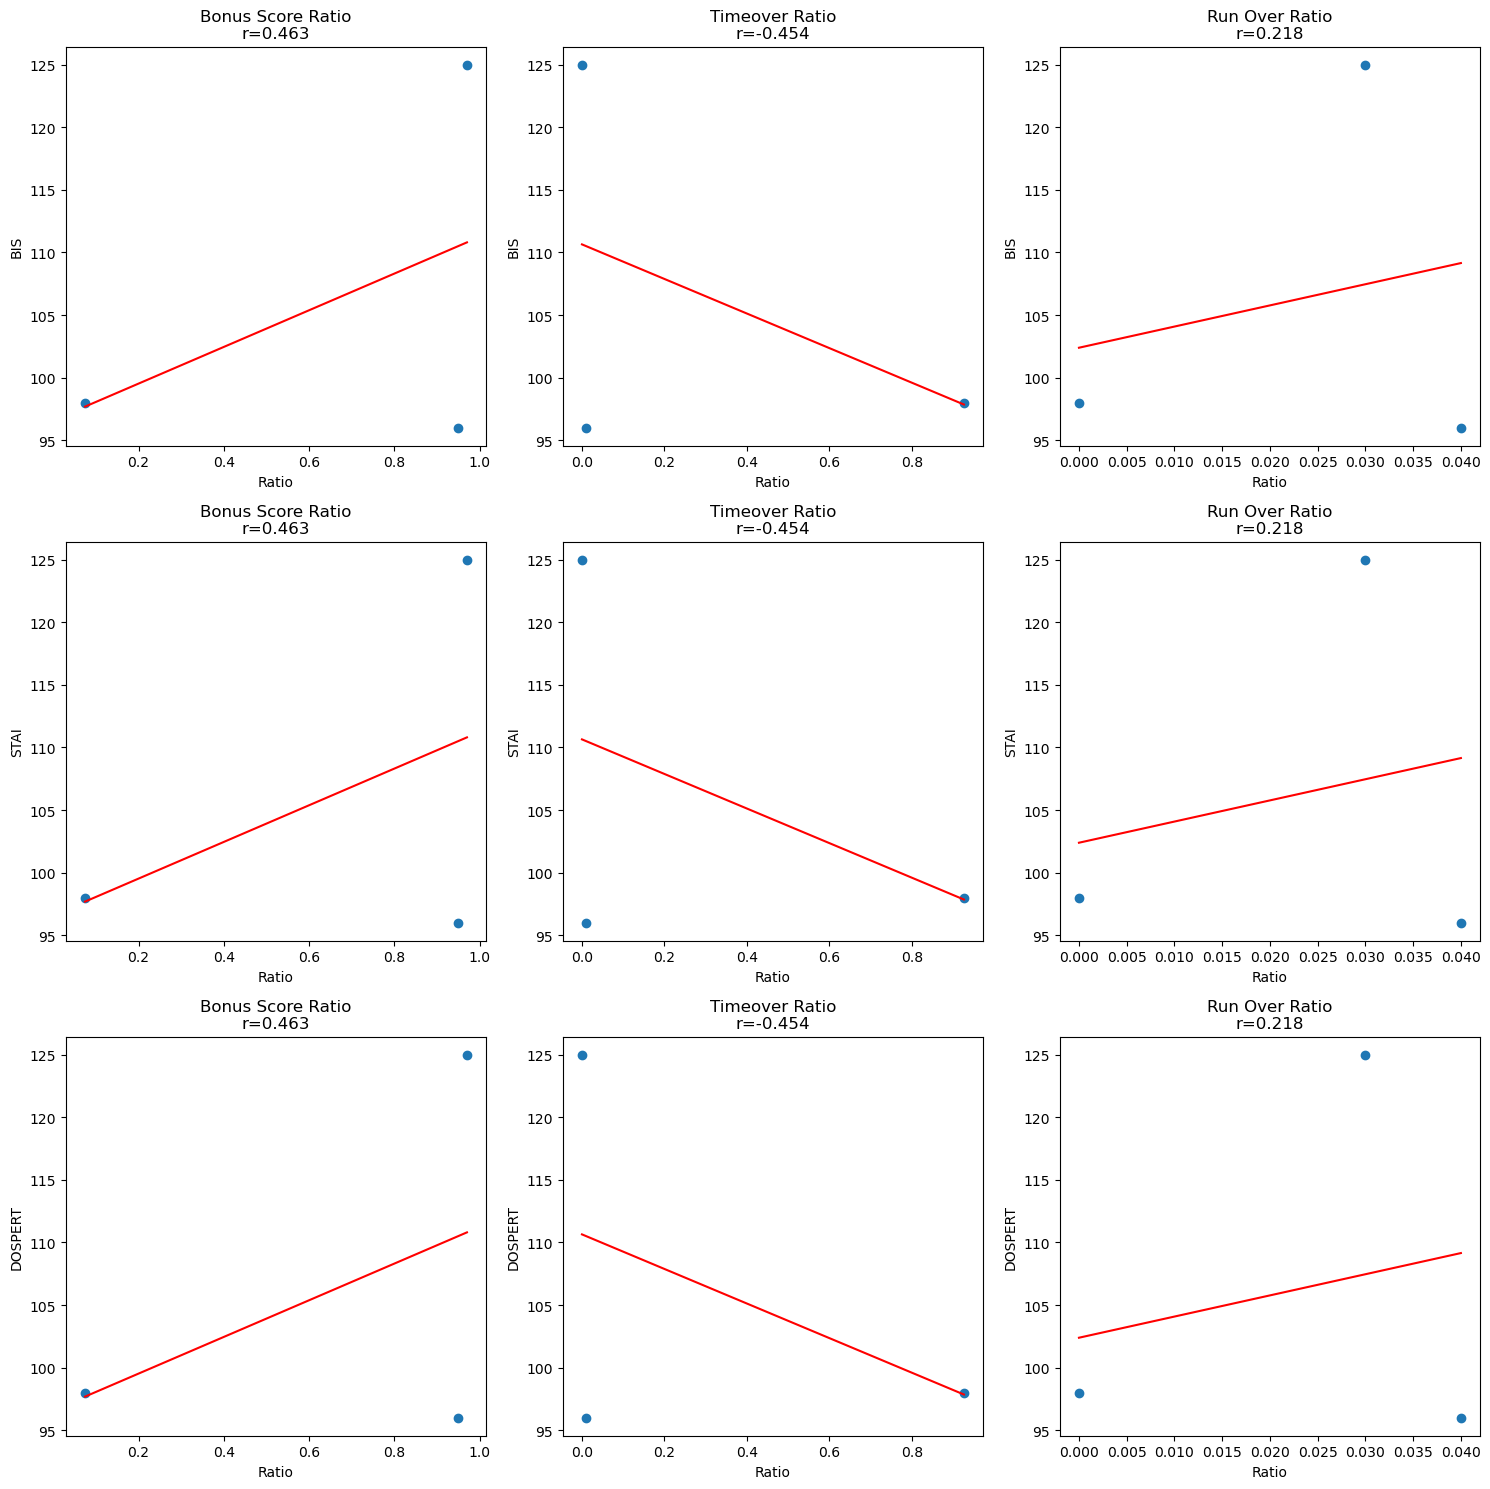

In [23]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 5 * row_count))
for i in range(row_count):
    questionnaire = questionnaires[i]
    for j in range(3):
        x = df[["bonus_score_episode_ratio", "timeover_episode_ratio", "run_over_episode_ratio"][j]]
        y = df[questionnaire]
        title = ["Bonus Score Ratio", "Timeover Ratio", "Run Over Ratio"][j]
        scatter_plot_with_line_regression(axes[i, j], x, y, "Ratio", questionnaire, title=title)

plt.tight_layout()
plt.show()

#### Run Over Ratio vs Impulsivity

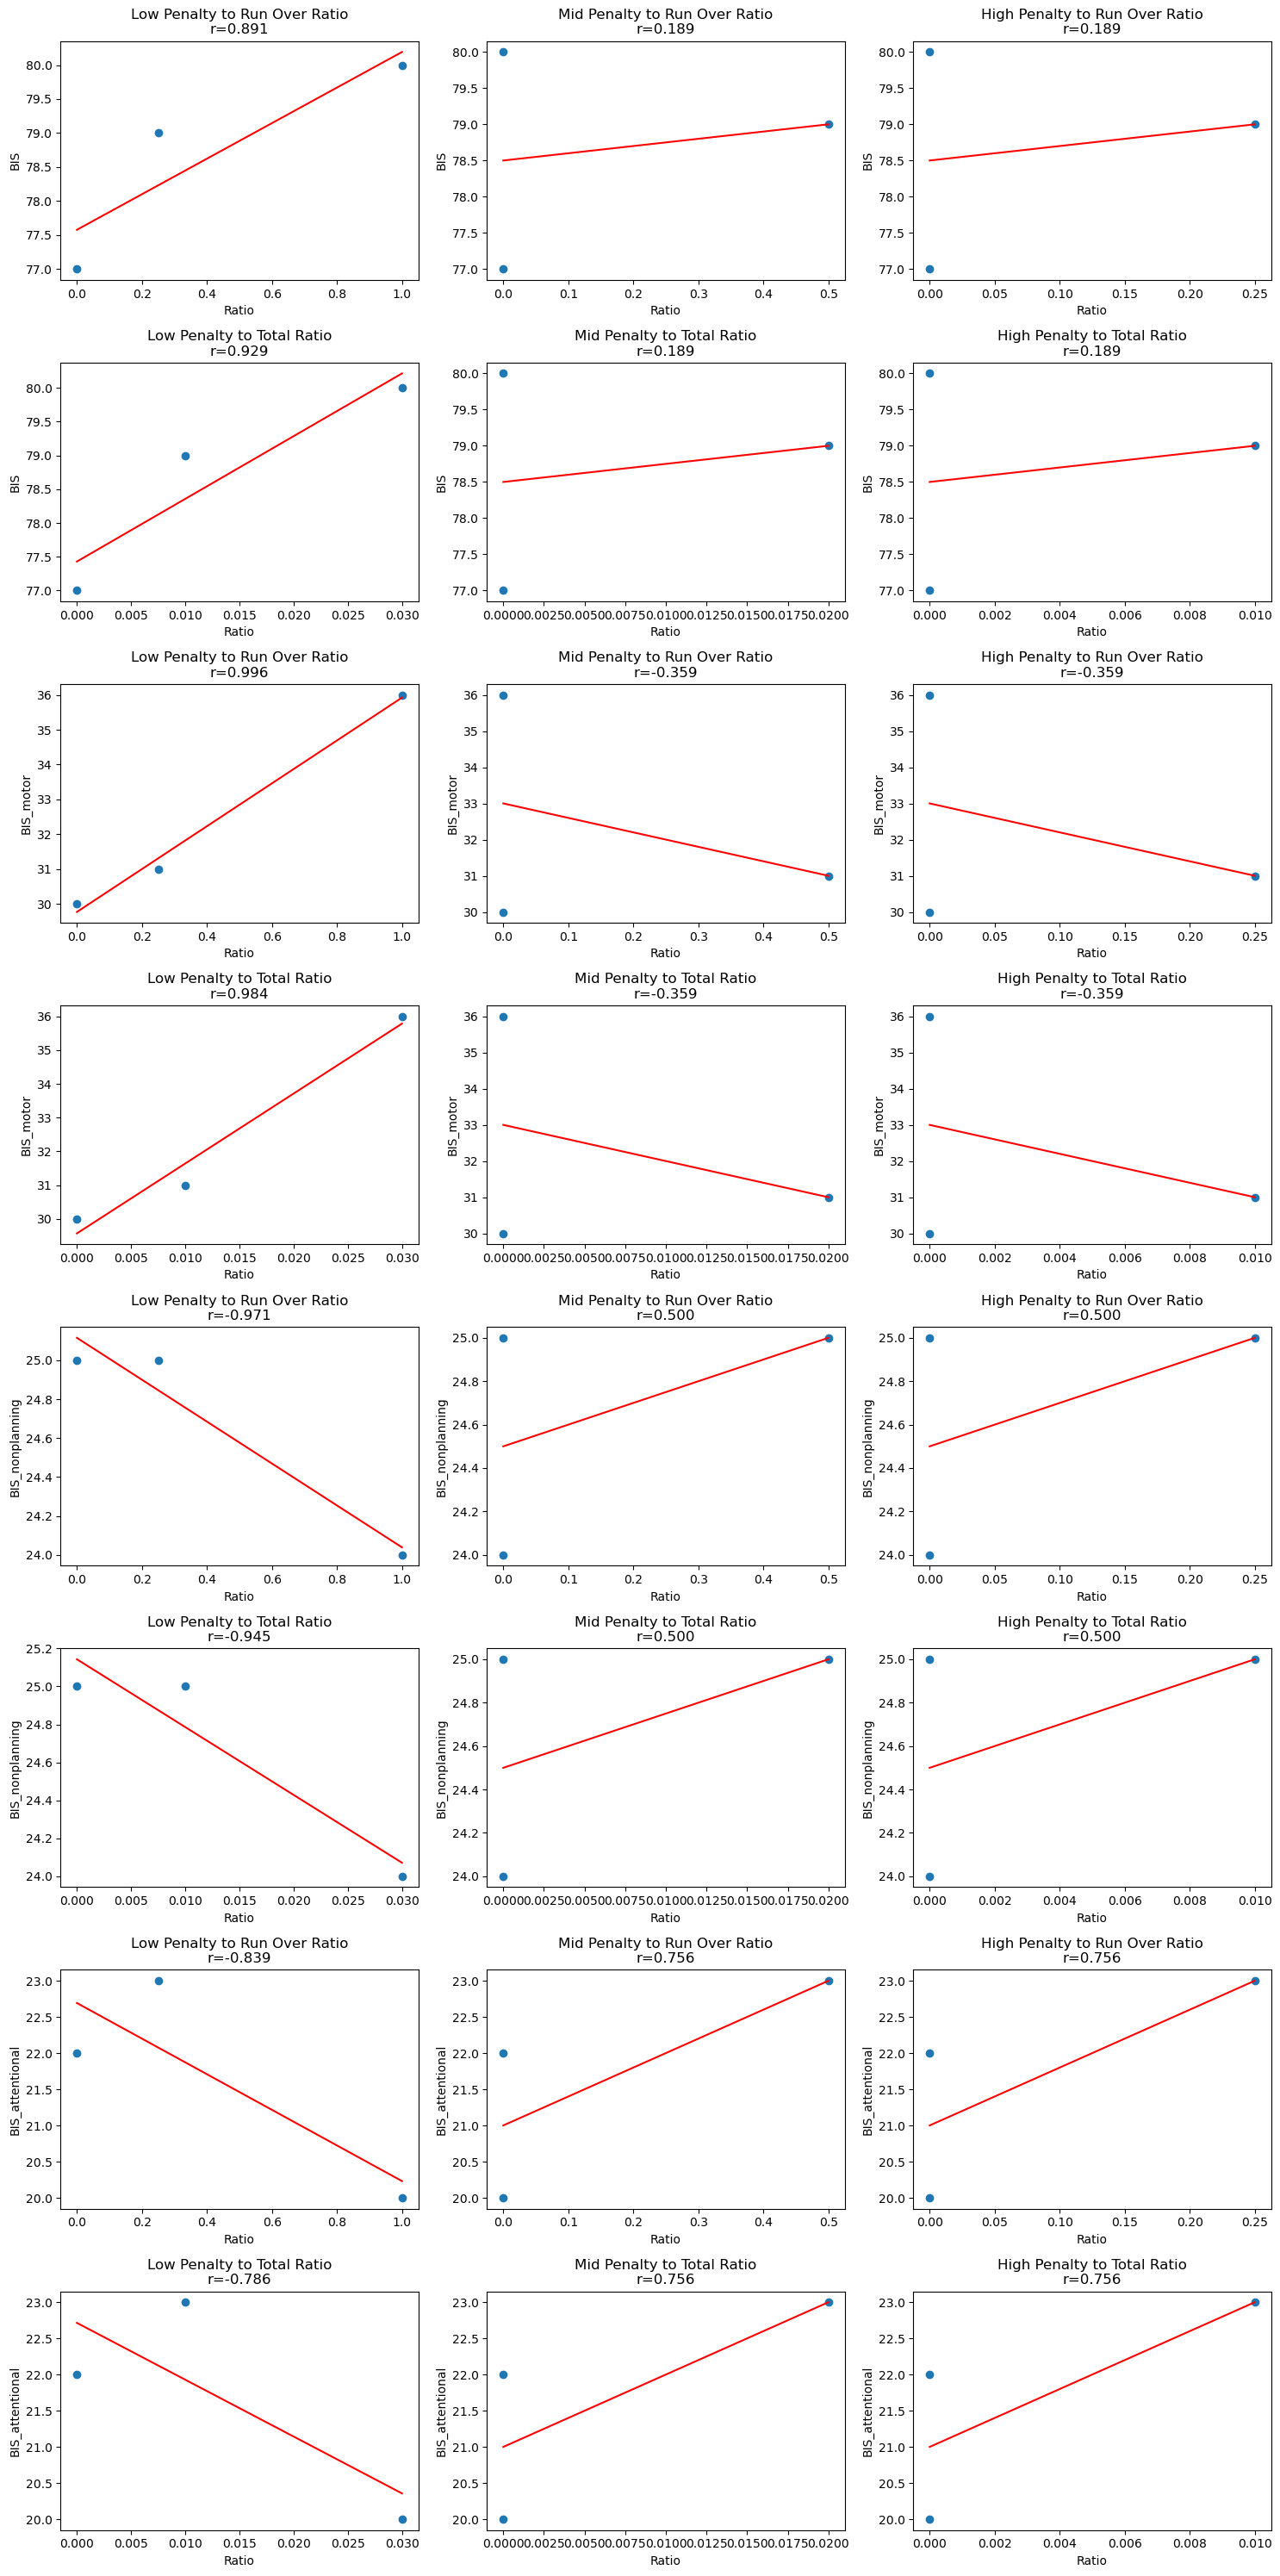

In [34]:
questionnaires = [
    "BIS", "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    # "STAI", "STAI_S", "STAI_T",
    # "DOSPERT", "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

fig, axes = plt.subplots(len(questionnaires) * 2, 3, figsize=(15, 5 * row_count))
for i in range(len(questionnaires)):
    questionnaire = questionnaires[i]
    for j in range(3):
        y = df[questionnaire]
        
        x = df[["low_penalty_ratio", "mid_penalty_ratio", "high_penalty_ratio"][j]]
        title = ["Low Penalty to Run Over Ratio", "Mid Penalty to Run Over Ratio", "High Penalty to Run Over Ratio"][j]
        scatter_plot_with_line_regression(axes[2*i, j], x, y, "Ratio", questionnaire, title=title)

        x = df[["low_penalty_full_ratio", "mid_penalty_full_ratio", "high_penalty_full_ratio"][j]]
        title = ["Low Penalty to Total Ratio", "Mid Penalty to Total Ratio", "High Penalty to Total Ratio"][j]
        scatter_plot_with_line_regression(axes[2*i+1, j], x, y, "Ratio", questionnaire, title=title)

plt.tight_layout()
plt.show()

### Locomotor Analysis

#### Action Proportions

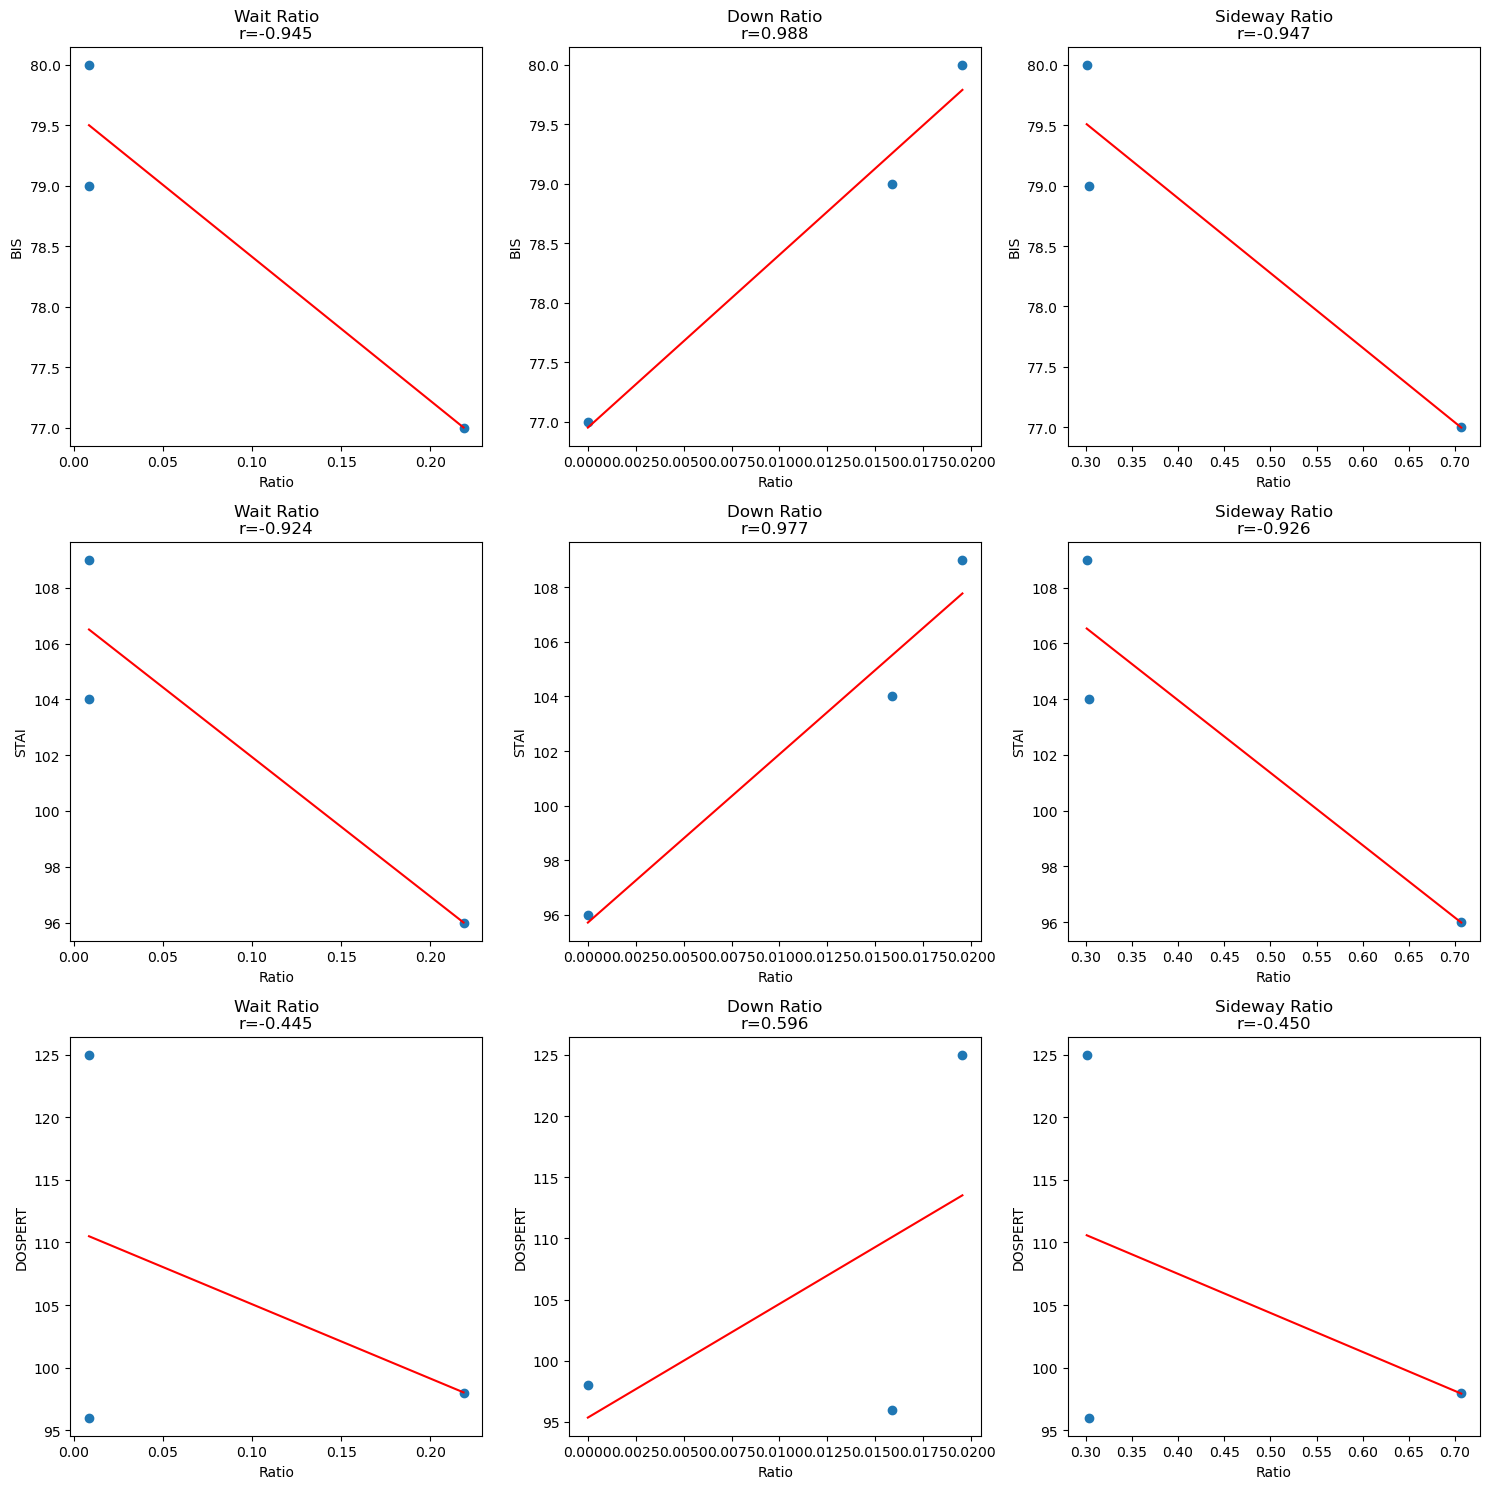

In [25]:
wait_ratio = df["action_Nothing_ratio"]
down_ratio = df["action_DOWN_ratio"]
sideway_movement_ratio = df["action_RIGHT_ratio"] + df["action_LEFT_ratio"]

questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]

row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 5 * row_count))
for i in range(row_count):
    questionnaire = questionnaires[i]
    for j in range(3):
        x = [wait_ratio, down_ratio, sideway_movement_ratio][j]
        y = df[questionnaire]
        title = ["Wait Ratio", "Down Ratio", "Sideway Ratio"][j]
        scatter_plot_with_line_regression(axes[i, j], x, y, "Ratio", questionnaire, title=title)

plt.tight_layout()
plt.show()

#### Visited Tiles

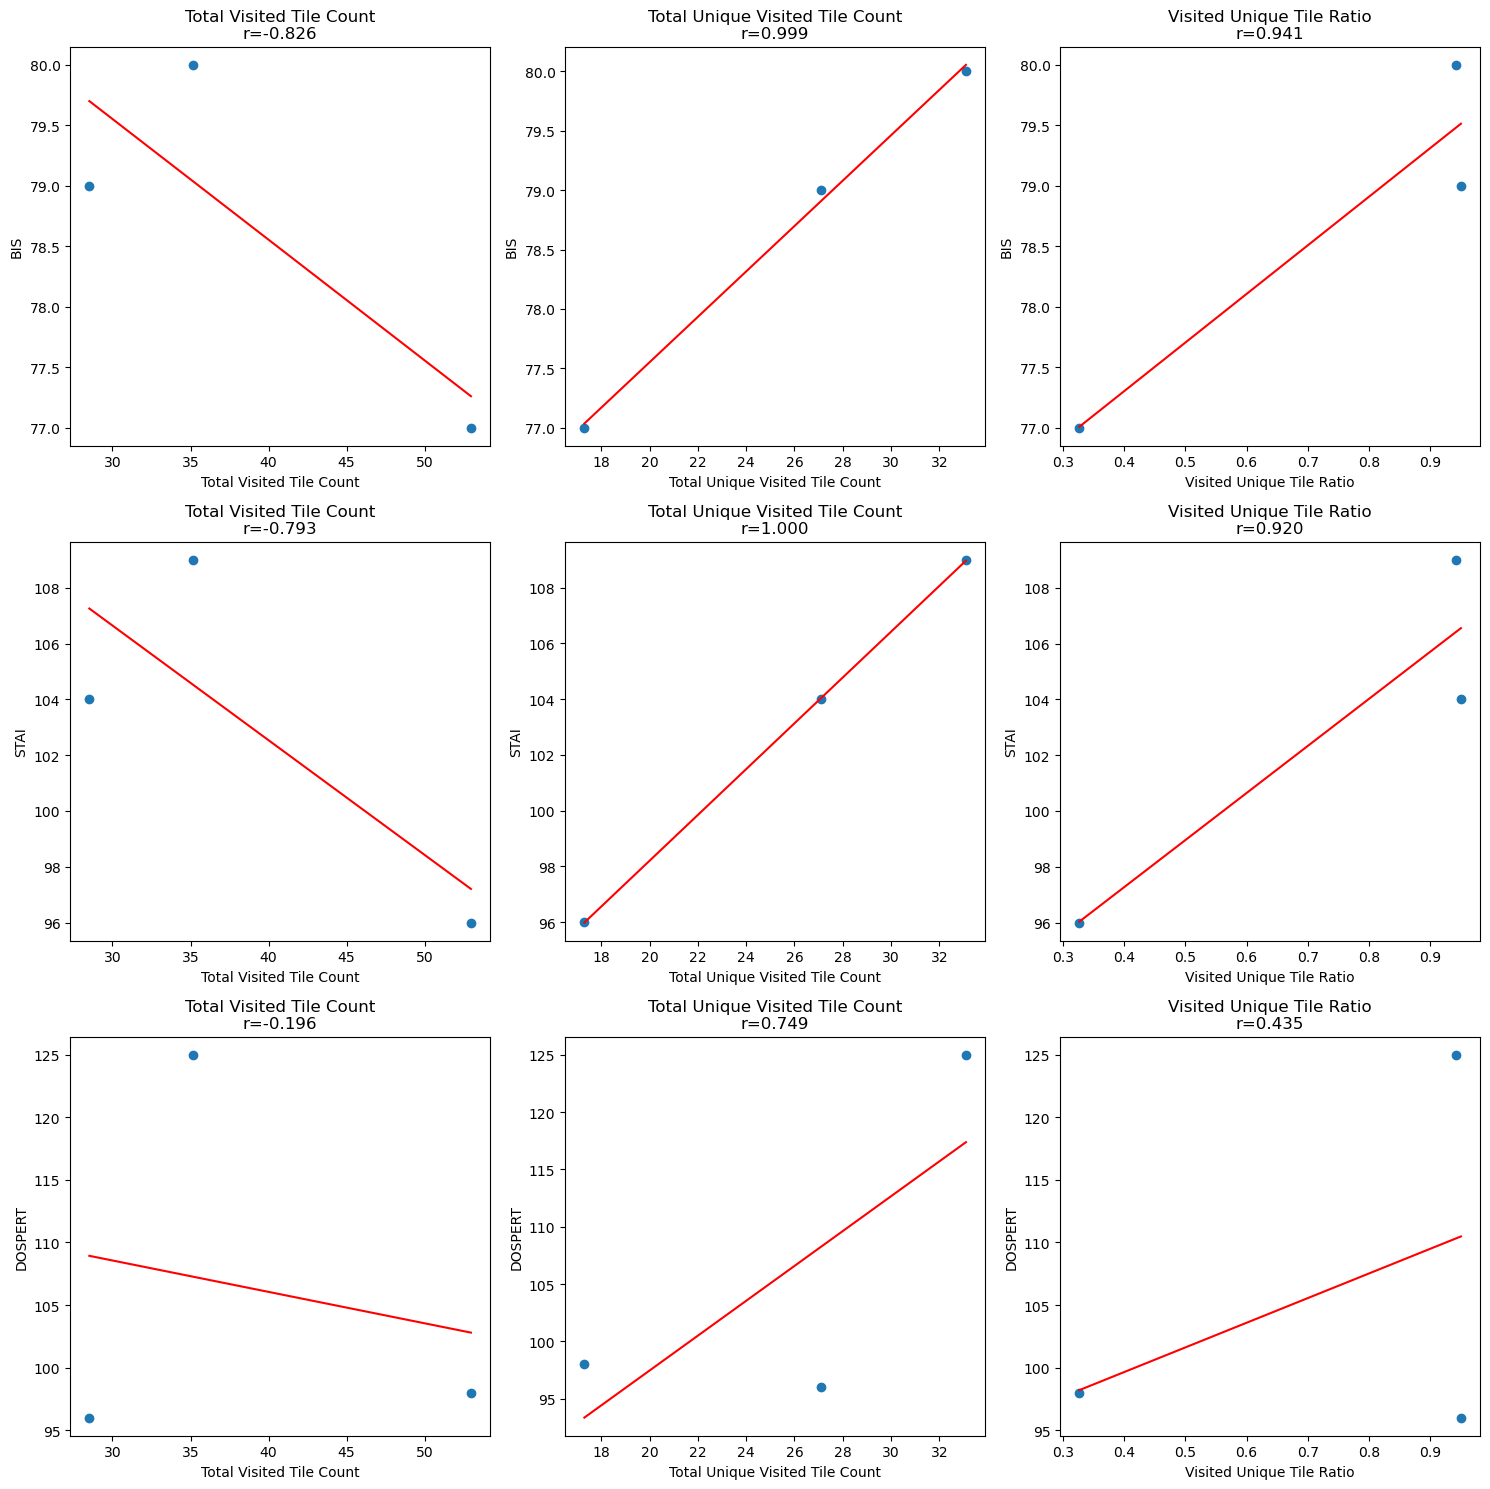

In [26]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]
row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 5 * row_count))
for i in range(row_count):
    questionnaire = questionnaires[i]
    for j in range(3):
        x = df[["visited_tile_cnt_mean", "visited_unique_tile_cnt_mean", "visited_unique_tile_ratio"][j]]
        y = df[questionnaire]
        xlabel = ["Total Visited Tile Count", "Total Unique Visited Tile Count", "Visited Unique Tile Ratio"][j]
        scatter_plot_with_line_regression(axes[i, j], x, y, xlabel, questionnaire, title=xlabel)

plt.tight_layout()
plt.show()